In [131]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
import time
import os
from matplotlib import font_manager

# Configure plotting fonts once to avoid CJK glyph warnings on systems without Chinese fonts.

In [132]:
def configure_matplotlib_fonts():
    cjk_font_candidates = [
        'PingFang SC',
        'Hiragino Sans GB',
        'Heiti SC',
        'STHeiti',
        'Songti SC',
        'Microsoft YaHei',
        'SimHei',
        'Noto Sans CJK SC',
        'Arial Unicode MS',
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next((name for name in cjk_font_candidates if name in available_fonts), None)

    if selected_font is not None:
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans', 'Arial']
        cjk_ok = True
    else:
        # Keep default font and use ASCII labels for dynamic text when CJK fonts are unavailable.
        cjk_ok = False

    plt.rcParams['axes.unicode_minus'] = False
    return cjk_ok


def configure_matplotlib_theme(theme='dark'):
    """Force a deterministic matplotlib theme so plots do not depend on IDE/session defaults."""
    if theme == 'dark':
        plt.style.use('dark_background')
        plt.rcParams.update({
            'figure.facecolor': '#111111',
            'axes.facecolor': '#111111',
            'savefig.facecolor': '#111111',
            'savefig.edgecolor': '#111111',
            'axes.edgecolor': '#D0D0D0',
            'axes.labelcolor': '#F2F2F2',
            'axes.titlecolor': '#F2F2F2',
            'xtick.color': '#D8D8D8',
            'ytick.color': '#D8D8D8',
            'grid.color': '#5A5A5A',
            'grid.alpha': 0.35,
            'legend.facecolor': '#1A1A1A',
            'legend.edgecolor': '#666666',
            'text.color': '#F2F2F2',
        })
    else:
        plt.style.use('default')


def configure_plotting(theme='dark'):
    cjk_ok = configure_matplotlib_fonts()
    configure_matplotlib_theme(theme=theme)
    return cjk_ok

# ==================== 电机模型参数 (保持不变) ====================

In [133]:

class PMSM:
    """永磁同步电机模型"""
    def __init__(self, Tl, dt):
        # 电机参数
        self.Rs = 2.875  # 定子电阻 (Ohm)
        self.Ld = 8.5e-3  # d轴电感 (H)
        self.Lq = 8.5e-3  # q轴电感 (H)
        self.J = 0.001  # 转动惯量 (kg·m²)
        self.B = 0.0001  # 阻尼系数 (N·m·s/rad)
        self.P = 4  # 极对数
        self.Phi_f = 0.175  # 永磁体磁链 (Wb)

        # 状态变量
        self.omega = 0.0  # 电角速度 (rad/s)
        self.theta = 0.0  # 电角度 (rad)
        self.id = 0.0  # d轴电流 (A)
        self.iq = 0.0  # q轴电流 (A)
        self.ialpha = 0.0
        self.ibeta  = 0.0
        self.TL = Tl  # 负载转矩 (N·m)

        # 离散时间步长
        self.dt = dt  # 100us采样时间

        # Numerical safety limits
        self.max_voltage = 4000.0
        self.max_current = 3000.0
        self.max_omega = 800.0
        self.max_derivative = 1e6

    def update(self, valpha, vbeta):
        """更新电机状态"""
        # Sanitize external inputs first
        valpha = float(np.nan_to_num(valpha, nan=0.0, posinf=self.max_voltage, neginf=-self.max_voltage))
        vbeta = float(np.nan_to_num(vbeta, nan=0.0, posinf=self.max_voltage, neginf=-self.max_voltage))
        valpha = float(np.clip(valpha, -self.max_voltage, self.max_voltage))
        vbeta = float(np.clip(vbeta, -self.max_voltage, self.max_voltage))

        # Keep state finite before derivative computation
        self.id = float(np.nan_to_num(self.id, nan=0.0, posinf=self.max_current, neginf=-self.max_current))
        self.iq = float(np.nan_to_num(self.iq, nan=0.0, posinf=self.max_current, neginf=-self.max_current))
        self.ialpha = float(np.nan_to_num(self.ialpha, nan=0.0, posinf=self.max_current, neginf=-self.max_current))
        self.ibeta = float(np.nan_to_num(self.ibeta, nan=0.0, posinf=self.max_current, neginf=-self.max_current))
        self.omega = float(np.nan_to_num(self.omega, nan=0.0, posinf=self.max_omega, neginf=-self.max_omega))

        vd = valpha * np.cos(self.theta) + vbeta * np.sin(self.theta)
        vq = -valpha * np.sin(self.theta) + vbeta * np.cos(self.theta)

        did_dt = (vd - self.Rs * self.id + self.omega * self.Lq * self.iq) / self.Ld
        diq_dt = (vq - self.Rs * self.iq - self.omega * (self.Ld * self.id + self.Phi_f)) / self.Lq


        Te = 1.5 * self.P * (self.Phi_f * self.iq + (self.Ld - self.Lq) * self.id * self.iq)
        domega_dt = (Te - self.TL - self.B * self.omega) / self.J

        # Clamp derivatives to prevent one-step explosion
        did_dt = float(np.clip(np.nan_to_num(did_dt, nan=0.0, posinf=self.max_derivative, neginf=-self.max_derivative), -self.max_derivative, self.max_derivative))
        diq_dt = float(np.clip(np.nan_to_num(diq_dt, nan=0.0, posinf=self.max_derivative, neginf=-self.max_derivative), -self.max_derivative, self.max_derivative))
        domega_dt = float(np.clip(np.nan_to_num(domega_dt, nan=0.0, posinf=self.max_derivative, neginf=-self.max_derivative), -self.max_derivative, self.max_derivative))

        self.id += did_dt * self.dt
        self.iq += diq_dt * self.dt
        self.omega += domega_dt * self.dt
        self.theta += self.omega * self.dt

        # Post-update clipping
        self.id = float(np.clip(self.id, -self.max_current, self.max_current))
        self.iq = float(np.clip(self.iq, -self.max_current, self.max_current))
        self.omega = float(np.clip(self.omega, -self.max_omega, self.max_omega))

        self.theta = self.theta % (2 * np.pi)

        self.ialpha, self.ibeta = inv_park_transform(self.id, self.iq, self.theta)

        return np.array([
            self.ialpha,
            self.ibeta,
            self.omega,
            self.theta,
        ], dtype=np.float32)

# ==================== PI控制器 (保持不变) ====================

In [134]:
class PI_controller:
    def __init__(self, kp, ki, dt):
        self.kp = kp
        self.ki = ki
        self.dt = dt

        self.integral = 0.0
        self.integral_limit = 300.0

    def update(self, error):
        error = float(np.nan_to_num(error, nan=0.0, posinf=1e6, neginf=-1e6))
        self.integral += error * self.dt
        self.integral = float(np.clip(self.integral, -self.integral_limit, self.integral_limit))
        return self.kp * error + self.ki * self.integral

# ==================== Park变换 (保持不变) ====================

In [135]:
def park_transform(i_alpha, i_beta, theta):
    i_alpha = float(np.nan_to_num(i_alpha, nan=0.0, posinf=0.0, neginf=0.0))
    i_beta = float(np.nan_to_num(i_beta, nan=0.0, posinf=0.0, neginf=0.0))
    theta = float(np.nan_to_num(theta, nan=0.0, posinf=0.0, neginf=0.0))
    i_d = i_alpha * np.cos(theta) + i_beta * np.sin(theta)
    i_q = -i_alpha * np.sin(theta) + i_beta * np.cos(theta)
    return i_d, i_q


def inv_park_transform(i_d, i_q, theta):
    i_alpha = i_d * np.cos(theta) - i_q * np.sin(theta)
    i_beta  = i_d * np.sin(theta) + i_q * np.cos(theta)
    return i_alpha, i_beta

# ==================== PINN-RNN 模型 ====================

In [136]:
class PhysicsInformedRNN(nn.Module):
    """
    物理信息递归神经网络 (PINN-RNN)
    结合电机物理方程作为归纳偏置，LSTM学习未建模动态
    """
    def __init__(self, motor_params, hidden_dim=128, latent_dim=32):
        super(PhysicsInformedRNN, self).__init__()

        # 保存电机参数
        self.Rs = motor_params.Rs * 1.7
        self.Ld = motor_params.Ld * 0.9
        self.Lq = motor_params.Lq * 1.2
        self.Phi_f = motor_params.Phi_f * 0.9
        self.J = motor_params.J
        self.B = motor_params.B
        self.P = motor_params.P
        self.dt = motor_params.dt

        # LSTM学习残差动态（物理模型未捕捉的部分）
        self.lstm = nn.LSTMCell(
            input_size=6,  # [id, iq, omega, theta, vd, vq]
            hidden_size=hidden_dim
        )

        # 从隐藏状态解码出状态残差
        self.residual_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4)  # 输出 [Δid, Δiq, Δω, Δθ]
        )

        # 不确定性估计（用于卡尔曼滤波或置信度评估）
        self.uncertainty_net = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 4),
            nn.Softplus()  # 确保方差为正
        )

        # 初始化权重
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)

    def physical_transition(self, x_k, u_k):
        """
        物理模型预测 (基于电机方程)
        输入:
            x_k: 当前状态 [id, iq, omega, theta]
            u_k: 控制输入 [vd, vq]
        返回:
            x_k1_physical: 物理模型预测的下一时刻状态
        """
        id, iq, omega, theta = x_k[:, 0], x_k[:, 1], x_k[:, 2], x_k[:, 3]
        vd, vq = u_k[:, 0], u_k[:, 1]

        # 电流动态方程
        did_dt = (vd - self.Rs * id + omega * self.Lq * iq) / self.Ld
        diq_dt = (vq - self.Rs * iq - omega * (self.Ld * id + self.Phi_f)) / self.Lq

        # 电磁转矩
        te = 1.5 * self.P * (self.Phi_f * iq + (self.Ld - self.Lq) * id * iq)

        # 机械方程
        domega_dt = (te - self.TL - self.B * omega) / self.J if hasattr(self, 'TL') else (te - self.B * omega) / self.J

        # 角度更新
        dtheta_dt = omega

        # 离散化
        x_k1_physical = x_k + torch.stack([
            did_dt * self.dt,
            diq_dt * self.dt,
            domega_dt * self.dt,
            dtheta_dt * self.dt
        ], dim=1)

        return x_k1_physical

    def forward(self, x_k, u_k, hidden_state=None):
        """
        前向传播：物理预测 + 神经网络残差

        参数:
            x_k: 当前状态 [batch, 4]
            u_k: 控制输入 [batch, 2]
            hidden_state: (hx, cx) LSTM隐藏状态，可选

        返回:
            x_k1: 预测的下一时刻状态
            hidden_state: 更新后的LSTM隐藏状态
            uncertainty: 预测的不确定性
        """
        batch_size = x_k.shape[0]

        # 物理预测
        x_k1_phy = self.physical_transition(x_k, u_k)

        # 构建LSTM输入 [id, iq, omega, theta, vd, vq]
        lstm_input = torch.cat([x_k, u_k], dim=1)

        # LSTM前向
        if hidden_state is None:
            hx = torch.zeros(batch_size, self.lstm.hidden_size).to(x_k.device)
            cx = torch.zeros(batch_size, self.lstm.hidden_size).to(x_k.device)
            hx, cx = self.lstm(lstm_input, (hx, cx))
        else:
            hx, cx = self.lstm(lstm_input, hidden_state)

        # 神经网络残差
        residual = self.residual_proj(hx)
        uncertainty = self.uncertainty_net(cx)

        # 组合预测：物理 + 残差
        x_k1 = x_k1_phy + residual

        return x_k1, (hx, cx), uncertainty

    def set_load_torque(self, TL):
        """设置负载转矩（用于物理方程）"""
        self.TL = TL


class PINN_RNN_Agent:
    """
    PINN-RNN智能体：用于电机状态预测和控制
    """
    def __init__(self, motor_params, state_dim=4, hidden_dim=128, lr=1e-3):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"使用设备: {self.device}")

        # GPU runtime hints
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass
        if self.device.type == "cuda":
            torch.backends.cudnn.benchmark = True

        # PINN-RNN模型
        self.model = PhysicsInformedRNN(motor_params, hidden_dim).to(self.device)

        # 优化器（CUDA上优先 fused AdamW）
        try:
            self.optimizer = optim.AdamW(
                self.model.parameters(), lr=lr, weight_decay=1e-5, fused=(self.device.type == "cuda")
            )
        except TypeError:
            self.optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-5)

        # 学习率调度器
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=500, gamma=0.5)

        # AMP
        self.use_amp = (self.device.type == "cuda")
        self.amp_dtype = torch.bfloat16 if (self.use_amp and torch.cuda.is_bf16_supported()) else torch.float16
        scaler_device = "cuda" if self.use_amp else "cpu"
        self.scaler = torch.amp.GradScaler(device=scaler_device, enabled=self.use_amp)

        # 经验回放缓冲区
        self.memory = deque(maxlen=100000)

        # 超参数（提升GPU占用）
        self.batch_size = 128
        self.sequence_length = 10

        self.train_count = 0
        self.motor_params = motor_params
        self.current_hidden = None

    def prepare_sequences(self, batch):
        """
        从经验回放中准备序列数据
        """
        sequences_x = []
        sequences_u = []
        targets = []

        for episode in batch:
            if len(episode) >= self.sequence_length + 1:
                # 随机选择一个起始点
                start = random.randint(0, len(episode) - self.sequence_length - 1)

                seq_x = []
                seq_u = []
                for i in range(self.sequence_length):
                    x_k = episode[start + i][0]  # 状态 [id, iq, omega, theta]
                    u_k = episode[start + i][1]  # 控制输入 [vd, vq]
                    seq_x.append(x_k)
                    seq_u.append(u_k)

                target = episode[start + self.sequence_length][0]  # 目标状态

                sequences_x.append(np.array(seq_x))
                sequences_u.append(np.array(seq_u))
                targets.append(target)

        if not sequences_x:
            return None

        # 转换为tensor
        seq_x_tensor = torch.FloatTensor(np.array(sequences_x)).to(self.device)
        seq_u_tensor = torch.FloatTensor(np.array(sequences_u)).to(self.device)
        targets_tensor = torch.FloatTensor(np.array(targets)).to(self.device)

        return seq_x_tensor, seq_u_tensor, targets_tensor

    def predict_next_state(self, current_state, vd, vq, update_hidden=True):
        """
        预测下一时刻状态

        参数:
            current_state: 当前状态 [id, iq, omega, theta]
            vd, vq: 当前施加的电压
            update_hidden: 是否更新内部隐藏状态（用于在线预测）

        返回:
            next_state_pred: 预测的下一时刻状态
            uncertainty: 预测不确定性
        """
        self.model.eval()

        with torch.no_grad():
            # 准备输入
            x_tensor = torch.FloatTensor(current_state).unsqueeze(0).to(self.device)
            u_tensor = torch.FloatTensor([[vd, vq]]).to(self.device)

            # 设置当前负载（如果已知）
            self.model.set_load_torque(self.motor_params.TL if hasattr(self.motor_params, 'TL') else 0)

            # 预测
            if update_hidden and self.current_hidden is not None:
                pred, hidden, uncertainty = self.model(x_tensor, u_tensor, self.current_hidden)
                self.current_hidden = hidden
            else:
                pred, hidden, uncertainty = self.model(x_tensor, u_tensor)
                if update_hidden:
                    self.current_hidden = hidden

            next_state_pred = pred.cpu().numpy()[0]
            uncertainty = uncertainty.cpu().numpy()[0]

        self.model.train()

        return next_state_pred, uncertainty

    def reset_hidden(self):
        """重置隐藏状态"""
        self.current_hidden = None

    def save_model(self, path):
        """保存模型"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
        }, path)
        print(f"模型已保存到 {path}")

    def load_model(self, path):
        """加载模型"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print(f"模型已从 {path} 加载")

    def train_step(self, replay_buffer):
        """GPU优化训练：批并行序列 + 单次optimizer.step"""
        if len(replay_buffer) < self.batch_size * (self.sequence_length + 1):
            return None

        self.model.train()
        self.model.set_load_torque(self.motor_params.TL if hasattr(self.motor_params, 'TL') else 0.0)

        batch = replay_buffer.sample_batch(
            batch_size=self.batch_size,
            episode_length=self.sequence_length
        )
        if batch is None:
            return None

        B = len(batch)
        T = self.sequence_length

        states_np = np.zeros((B, T, 4), dtype=np.float32)
        controls_np = np.zeros((B, T, 2), dtype=np.float32)
        targets_np = np.zeros((B, T, 4), dtype=np.float32)

        valid = 0
        for b, episode in enumerate(batch):
            if len(episode) < T + 1:
                continue
            for t in range(T):
                s = np.asarray(episode[t]['state'], dtype=np.float32)[:4]
                ns = np.asarray(episode[t + 1]['state'], dtype=np.float32)[:4]
                vd = float(episode[t]['vd'])
                vq = float(episode[t]['vq'])
                states_np[b, t] = s
                controls_np[b, t] = [vd, vq]
                targets_np[b, t] = ns
            valid += 1

        if valid == 0:
            return None

        if valid < B:
            states_np = states_np[:valid]
            controls_np = controls_np[:valid]
            targets_np = targets_np[:valid]

        states = torch.from_numpy(states_np).to(self.device, non_blocking=True)
        controls = torch.from_numpy(controls_np).to(self.device, non_blocking=True)
        targets = torch.from_numpy(targets_np).to(self.device, non_blocking=True)

        self.optimizer.zero_grad(set_to_none=True)
        hidden = None
        preds = []
        uncertainties = []

        with torch.autocast(
            device_type=self.device.type,
            dtype=self.amp_dtype,
            enabled=self.use_amp
        ):
            for t in range(T):
                pred, hidden, uncertainty = self.model(states[:, t, :], controls[:, t, :], hidden)
                preds.append(pred)
                uncertainties.append(uncertainty)

            pred_stack = torch.stack(preds, dim=1)
            uncertainty_stack = torch.stack(uncertainties, dim=1)

            # 速度导向 + 角度环形误差（避免2π跳变放大loss）
            omega_loss = F.mse_loss(pred_stack[:, :, 2], targets[:, :, 2])
            current_loss = F.mse_loss(pred_stack[:, :, :2], targets[:, :, :2])
            theta_diff = pred_stack[:, :, 3] - targets[:, :, 3]
            theta_wrapped = torch.atan2(torch.sin(theta_diff), torch.cos(theta_diff))
            theta_loss = torch.mean(theta_wrapped ** 2)

            reconstruction_loss = F.mse_loss(pred_stack[:, :, :4], targets[:, :, :4], reduction='none')
            variance = uncertainty_stack + 1e-6  # 避免除零
            nll_loss = torch.mean(0.5 * reconstruction_loss / variance + 0.5 * torch.log(variance))

            loss = 0.6 * omega_loss + 0.25 * current_loss + 0.1 * theta_loss + 0.05 * nll_loss

        if self.use_amp:
            prev_scale = self.scaler.get_scale()
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            step_ok = self.scaler.get_scale() >= prev_scale
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()
            step_ok = True

        if step_ok:
            self.scheduler.step()

        self.train_count += 1
        return float(loss.detach().item())

# ==================== 经验回放缓冲区 (修改为支持序列) ====================

In [137]:
class SequenceReplayBuffer:
    """
    支持序列存储的经验回放缓冲区
    """
    def __init__(self, max_size=1e5):
        self.buffer = deque(maxlen=int(max_size))

    def push(self, state, action, reward,  done, vd, vq):
        # next_state,
        """存储单步经验"""
        # 确保状态是4维
        if len(state) > 4:
            state = state[:4]
        '''if len(next_state) > 4:
            next_state = next_state[:4]
            '''


        self.buffer.append({
            'state': state.copy(),
            'action': action.copy() if isinstance(action, np.ndarray) else action,
            'reward': reward,
            # 'next_state': next_state.copy(),
            'done': done,
            'vd': vd,
            'vq': vq
        })

    def sample_episode(self, episode_length=10):
        """采样一个完整的episode序列"""
        if len(self.buffer) < episode_length + 1:
            return None

        # 随机选择一个起始点
        start = random.randint(0, len(self.buffer) - episode_length - 1)

        episode = []
        for i in range(episode_length + 1):  # +1 是为了有目标值
            idx = start + i
            episode.append(self.buffer[idx])

        return episode

    def sample_batch(self, batch_size=32, episode_length=10):
        """采样一批episode序列"""
        if len(self.buffer) < episode_length + 1:
            return None

        batch = []
        for _ in range(batch_size):
            episode = self.sample_episode(episode_length)
            if episode:
                batch.append(episode)

        return batch if batch else None

    def __len__(self):
        return len(self.buffer)

# ==================== FOC控制 (修改为使用PINN-RNN) ====================

In [138]:
class FocControl:
    def __init__(self, speed_ref=314.16, Tl=0, dt=1e-5):
        # Motor model
        self.motor = PMSM(Tl, dt)
        self.motor_state = self.motor.update(0, 0)

        # PINN-RNN智能体
        self.pinn_agent = PINN_RNN_Agent(self.motor, hidden_dim=128, lr=1e-3)
        self.pred_omega = 0.0  # 预测的速度（用于前馈控制）
        self.pred_theta = 0.0

        # Set PI-controllers for speed, id and iq
        self.speed_controller = PI_controller(kp=6, ki=340, dt=self.motor.dt)
        self.id_controller = PI_controller(kp=200, ki=1000, dt=self.motor.dt)
        self.iq_controller = PI_controller(kp=200, ki=1000, dt=self.motor.dt)

        # Initialize control variables
        self.v_alpha = 0.0
        self.v_beta = 0.0
        self.speed_ref = speed_ref  # 目标速度 (rad/s)
        self.i_d_ref = 0

        # 状态历史（用于训练）
        self.state_history = []
        self.control_history = []

        # 上次的电压值
        self.last_vd = 0.0
        self.last_vq = 0.0

    def reset_runtime_state(self, speed_ref=0.0, Tl=0.0):
        """重置控制器、电机和RNN运行态，避免测试与训练互相污染。"""
        self.motor.id = 0.0
        self.motor.iq = 0.0
        self.motor.omega = 0.0
        self.motor.theta = 0.0
        self.motor.ialpha = 0.0
        self.motor.ibeta = 0.0
        self.motor.TL = Tl
        self.motor_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

        self.pred_omega = 0.0
        self.pred_theta = 0.0
        self.v_alpha = 0.0
        self.v_beta = 0.0
        self.last_vd = 0.0
        self.last_vq = 0.0
        self.speed_ref = speed_ref
        self.i_d_ref = 0.0

        self.speed_controller.integral = 0.0
        self.id_controller.integral = 0.0
        self.iq_controller.integral = 0.0

        self.state_history.clear()
        self.control_history.clear()
        self.pinn_agent.reset_hidden()
        self.pinn_agent.motor_params = self.motor

    def update(self, speed_ref=314.16, Tl=0.001, omega=0.0, theta=0.0):
        self.motor.TL = Tl
        self.speed_ref = speed_ref

        # 更新电机状态（使用上次的电压）
        self.motor_state = self.motor.update(self.v_alpha, self.v_beta)

        # 从电机获取当前电流
        i_alpha, i_beta = self.motor_state[0], self.motor_state[1]
        i_d, i_q = park_transform(i_alpha, i_beta, theta)

        # 当前状态 [id, iq, omega, theta]
        current_state = np.array([i_d, i_q, omega, theta], dtype=np.float32)

        # PINN-RNN预测下一状态（用于前馈控制）
        if len(self.state_history) > 5:  # 有足够历史数据后才使用预测
            next_state_pred, uncertainty = self.pinn_agent.predict_next_state(
                current_state, self.last_vd, self.last_vq, update_hidden=True
            )
            self.pred_omega = float(next_state_pred[2])
        else:
            self.pred_omega = omega

        self.pred_theta += (omega * self.motor.dt)
        self.pred_theta %= (2 * np.pi)

        # PI-control (可以使用预测的速度进行前馈补偿)
        speed_error = self.speed_ref - omega
        # 可以添加基于预测的前馈项
        feedforward = 0.0
        if len(self.state_history) > 5:
            feedforward = 0.1 * (self.pred_omega - omega)  # 简单的速度前馈

        i_q_ref = self.speed_controller.update(speed_error) + feedforward

        # Get vd vq from the PI-controllers
        v_q = self.iq_controller.update(i_q_ref - i_q)
        v_d = self.id_controller.update(self.i_d_ref - i_d)

        # 保存电压值（用于下一时刻的预测）
        self.last_vd = v_d
        self.last_vq = v_q
        self.v_alpha, self.v_beta = inv_park_transform(v_d, v_q, theta)

        reward = -0.1 * np.abs(speed_error)
        done = False

        # 存储状态历史（用于训练）
        self.state_history.append(current_state)
        self.control_history.append([v_d, v_q])
        if len(self.state_history) > 1000:  # 限制历史长度
            self.state_history.pop(0)
            self.control_history.pop(0)

        return reward, np.array([i_d, i_q, v_d, v_q, omega], dtype=np.float32), done

    def train_pinn(self, replay_buffer, batch_size=32):
        """训练PINN-RNN模型（调用GPU优化版）"""
        self.pinn_agent.batch_size = int(batch_size)
        return self.pinn_agent.train_step(replay_buffer)

# ==================== 训练函数 ====================

In [139]:
def train_pinn_rnn(
    focEnv,
    replay_buffer,
    total_time=0.5,
    dt=1e-5,
    warmup_ratio=0.1,
    batch_size=16,
    train_interval=1000,
    enable_training=True,
    save_path='pinn_rnn_motor.pth',
    max_train_load=8.0
):
    """
    训练PINN-RNN模型（多阶段训练策略）

    参数:
        focEnv: FOC控制环境
        replay_buffer: 经验回放缓冲区
        total_time: 总仿真时间 (s)
        dt: 时间步长 (s)
        warmup_ratio: 预热数据比例
        batch_size: 训练批次大小
        train_interval: 每多少步打印一次训练状态
        enable_training: 是否启用训练
        save_path: 模型保存路径
        max_train_load: 最大训练负载

    返回:
        dict: 训练过程中的记录数据
    """
    print("=" * 60)
    print("开始PINN-RNN训练（多阶段策略）...")
    print("=" * 60)

    time_steps = int(total_time / dt)

    # 定义训练阶段：(起始步比例, 结束步比例, 目标速度, 目标负载, 阶段名称)
    training_phases = [
        (0.00, 0.15, 100.0,   2.0, "低速轻载 ramp-up"),
        (0.15, 0.30, 100.0,   2.0, "低速轻载 steady"),
        (0.30, 0.45, 200.0,   5.0, "中速中载 ramp-up"),
        (0.45, 0.60, 200.0,   5.0, "中速中载 steady"),
        (0.60, 0.75, 314.16, 10.0, "高速重载 ramp-up"),
        (0.75, 0.90, 314.16, 10.0, "高速重载 steady"),
        (0.90, 1.00, 314.16, max_train_load, "极限负载测试"),
    ]

    print(f"总仿真步数: {time_steps}")
    print(f"批次大小: {batch_size}")
    print(f"训练间隔: {train_interval}")
    print(f"\n训练阶段:")
    for i, (start, end, speed, load, name) in enumerate(training_phases):
        steps = int((end - start) * time_steps)
        print(f"  阶段{i+1}: {name:20s} | 速度={speed:7.2f} rad/s | 负载={load:5.1f} N·m | 步数={steps:6d}")
    print("=" * 60)

    # 初始化变量
    omega, theta = 0.0, 0.0
    speed_ref, Tl = 0.0, 0.0
    current_phase = 0

    # 记录数据
    records = {
        'time': [],
        'i_d': [],
        'i_q': [],
        'omega': [],
        'theta': [],
        'pinn_loss': [],
        'step_reward': [],
        'total_reward': 0,
        'phase_labels': [],  # 记录每个时间点所属的训练阶段
        'speed_ref_history': [],
        'load_ref_history': []
    }

    # 重置环境
    replay_buffer.buffer.clear()
    if hasattr(focEnv, 'reset_runtime_state'):
        focEnv.reset_runtime_state(speed_ref=0.0, Tl=0.0)
    else:
        focEnv.pinn_agent.reset_hidden()

    start_time = time.time()

    for step in range(time_steps):
        # 确定当前阶段
        progress = step / time_steps
        for i, (start, end, target_speed, target_load, phase_name) in enumerate(training_phases):
            if start <= progress < end:
                current_phase = i
                break

        # 获取当前阶段的目标值
        _, _, target_speed, target_load, _ = training_phases[current_phase]

        # 计算当前阶段的起始步
        phase_start_step = int(training_phases[current_phase][0] * time_steps)
        phase_progress = (step - phase_start_step) / max(1, int((training_phases[current_phase][1] - training_phases[current_phase][0]) * time_steps))

        # 在每个阶段的前20%时间内做平滑过渡
        if phase_progress < 0.2 and current_phase > 0:
            # 从前一个阶段的目标值平滑过渡到当前阶段
            prev_speed = training_phases[current_phase - 1][2]
            prev_load = training_phases[current_phase - 1][3]
            speed_ref = prev_speed + (target_speed - prev_speed) * (phase_progress / 0.2)
            Tl = prev_load + (target_load - prev_load) * (phase_progress / 0.2)
        else:
            speed_ref = target_speed
            Tl = target_load

        reward, next_state, done = focEnv.update(
            speed_ref=speed_ref,
            Tl=Tl,
            omega=omega,
            theta=theta
        )

        vd = focEnv.last_vd
        vq = focEnv.last_vq

        # 训练样本统一使用电机真实状态
        full_state = np.array([
            focEnv.motor.id,
            focEnv.motor.iq,
            focEnv.motor.omega,
            focEnv.motor.theta
        ], dtype=np.float32)

        replay_buffer.push(
            full_state,
            np.array([0]),
            float(reward),
            float(done),
            vd,
            vq
        )

        # 训练PINN-RNN
        if enable_training and len(replay_buffer) >= 1000:
            loss = focEnv.train_pinn(replay_buffer, batch_size=batch_size)
            if loss is not None:
                records['pinn_loss'].append(loss)

        # 更新状态
        state = next_state.astype(np.float32)

        # 获取电流值
        i_d = float(focEnv.motor.id)
        i_q = float(focEnv.motor.iq)

        # 更新omega和theta
        omega = float(focEnv.motor.omega)
        theta += (omega * dt)
        theta %= (2 * np.pi)

        # 记录数据
        records['time'].append(step * dt)
        records['i_d'].append(i_d)
        records['i_q'].append(i_q)
        records['omega'].append(omega)
        records['theta'].append(theta)
        records['step_reward'].append(reward)
        records['total_reward'] += reward
        records['phase_labels'].append(current_phase)
        records['speed_ref_history'].append(speed_ref)
        records['load_ref_history'].append(Tl)

        # 打印训练状态
        if step % train_interval == 0 and step > 0:
            elapsed = time.time() - start_time
            avg_loss = np.mean(records['pinn_loss'][-100:]) if records['pinn_loss'] else 0
            phase_name = training_phases[current_phase][4]
            print(f"[训练] Step {step:6d}/{time_steps} | "
                  f"Phase: {phase_name:20s} | "
                  f"Speed Ref: {speed_ref:7.2f} | "
                  f"Load: {Tl:5.1f} | "
                  f"Avg Loss: {avg_loss:.6f} | "
                  f"Actual Speed: {omega:7.2f} | "
                  f"Buffer: {len(replay_buffer)} | "
                  f"Elapsed: {elapsed:.1f}s")

    # 保存模型
    if enable_training:
        focEnv.pinn_agent.save_model(save_path)
        print(f"\n模型已保存到 {save_path}")

    total_time_elapsed = time.time() - start_time
    print(f"\n训练完成！总耗时: {total_time_elapsed:.2f}s")
    print(f"总奖励: {records['total_reward']:.2f}")
    print(f"最终速度: {omega:.2f} rad/s")

    return records

# ==================== 测试函数 ====================

In [140]:
def test_pinn_rnn(
    focEnv,
    test_time=0.2,
    dt=1e-5,
    test_speed=314.16,
    test_load=5.0,
    show_plots=True,
    plot_title_prefix="",
    prediction_mode='one_step',
    challenge_profile=False,
    input_noise_std=0.0
):
    """
    测试PINN-RNN模型的预测能力

    参数:
        focEnv: FOC控制环境
        test_time: 测试时间 (s)
        dt: 时间步长 (s)
        test_speed: 测试目标速度 (rad/s)
        test_load: 测试负载转矩
        show_plots: 是否显示图表
        plot_title_prefix: 图表标题前缀
        prediction_mode: 'one_step' 或 'rollout'
            - one_step: 每一步使用真实状态作为模型输入（误差通常较小）
            - rollout: 仅用模型上一步预测作为下一步输入（误差会累积，更能暴露参数偏差）
        challenge_profile: 是否启用高激励测试工况（多段速度/负载变化）
        input_noise_std: 模型输入电压噪声标准差（仅对模型输入生效）

    返回:
        dict: 测试结果
    """
    if prediction_mode not in ('one_step', 'rollout'):
        raise ValueError("prediction_mode must be 'one_step' or 'rollout'")

    print("\n" + "=" * 60)
    print("开始PINN-RNN测试...")
    print("=" * 60)

    test_steps = int(test_time / dt)

    print(f"测试模式: {prediction_mode}")
    print(f"挑战工况: {challenge_profile}")
    print(f"输入噪声标准差: {input_noise_std}")
    print(f"测试时间: {test_time}s")
    print(f"测试步数: {test_steps}")
    print(f"目标速度: {test_speed:.2f} rad/s")
    print(f"负载转矩: {test_load:.2f} N·m")
    print("=" * 60)

    # 重置环境
    if hasattr(focEnv, 'reset_runtime_state'):
        focEnv.reset_runtime_state(speed_ref=test_speed, Tl=test_load)
    else:
        focEnv.pinn_agent.reset_hidden()
    omega, theta = 0.0, 0.0

    # 数值保护阈值
    max_speed_guard = float(getattr(focEnv.motor, 'max_omega', 800.0) * 4.0)
    max_state_guard = max_speed_guard

    # 记录数据
    predictions = []
    actuals = []
    uncertainties = []
    times = []
    errors = []

    # 获取初始状态
    current_state = np.array([
        focEnv.motor.id,
        focEnv.motor.iq,
        focEnv.motor.omega,
        focEnv.motor.theta
    ], dtype=np.float32)

    # rollout 模式下使用模型自身状态递推
    model_rollout_state = current_state.copy()

    start_time = time.time()

    for step in range(test_steps):
        if challenge_profile:
            phase = step / max(1, test_steps - 1)
            if phase < 0.25:
                speed_ref_now = 0.6 * test_speed
                load_now = 0.5 * test_load
            elif phase < 0.50:
                speed_ref_now = 1.2 * test_speed
                load_now = 1.2 * test_load
            elif phase < 0.75:
                speed_ref_now = 0.8 * test_speed
                load_now = 1.6 * test_load
            else:
                speed_ref_now = test_speed
                load_now = 2.0 * test_load

            speed_ref_now += 0.05 * test_speed * np.sin(2 * np.pi * 6 * phase)
            load_now += 0.10 * test_load * np.sin(2 * np.pi * 9 * phase)
        else:
            speed_ref_now = test_speed
            load_now = test_load

        # 固定测试条件（电机真实系统）
        reward, next_state, done = focEnv.update(
            speed_ref=speed_ref_now,
            Tl=load_now,
            omega=current_state[2],
            theta=current_state[3]
        )

        vd = focEnv.last_vd
        vq = focEnv.last_vq

        # 模型输入可选加入噪声，放大参数失配影响
        if input_noise_std > 0.0:
            vd_model = vd + np.random.normal(0.0, input_noise_std)
            vq_model = vq + np.random.normal(0.0, input_noise_std)
        else:
            vd_model, vq_model = vd, vq

        model_input_state = current_state if prediction_mode == 'one_step' else model_rollout_state

        # 预测下一状态
        pred_state, uncertainty = focEnv.pinn_agent.predict_next_state(
            model_input_state, vd_model, vq_model
        )

        # 数值清洗，避免inf/nan传导到统计和绘图
        pred_state = np.nan_to_num(pred_state, nan=0.0, posinf=max_state_guard, neginf=-max_state_guard)
        pred_state = np.clip(pred_state, -max_state_guard, max_state_guard)
        uncertainty = np.nan_to_num(uncertainty, nan=0.0, posinf=max_state_guard, neginf=0.0)
        uncertainty = np.clip(uncertainty, 0.0, max_state_guard)

        if prediction_mode == 'rollout':
            model_rollout_state = pred_state.astype(np.float32)
            pred_speed = float(model_rollout_state[2])
        else:
            pred_speed = float(pred_state[2])

        # 记录数据
        actual_speed = float(np.nan_to_num(focEnv.motor.omega, nan=0.0, posinf=max_speed_guard, neginf=-max_speed_guard))
        actual_speed = float(np.clip(actual_speed, -max_speed_guard, max_speed_guard))

        error_value = abs(actual_speed - pred_speed)
        if not np.isfinite(error_value):
            error_value = max_speed_guard

        predictions.append(pred_speed)
        actuals.append(actual_speed)
        uncertainties.append(float(uncertainty[2]))  # 速度的不确定性
        times.append(step * dt)
        errors.append(float(error_value))

        # 更新当前真实状态
        current_state = np.array([
            focEnv.motor.id,
            focEnv.motor.iq,
            focEnv.motor.omega,
            focEnv.motor.theta
        ], dtype=np.float32)

        # 每100步打印一次进度
        if step % 100 == 0 and step > 0:
            print(f"[测试] Step {step:4d}/{test_steps} | "
                  f"Actual: {actual_speed:9.2f} rad/s | "
                  f"Pred: {pred_speed:9.2f} rad/s | "
                  f"Error: {errors[-1]:8.3f} rad/s")

    test_time_elapsed = time.time() - start_time

    # 计算统计指标（仅使用有限值）
    predictions = np.asarray(predictions, dtype=np.float64)
    actuals = np.asarray(actuals, dtype=np.float64)
    uncertainties = np.asarray(uncertainties, dtype=np.float64)
    errors = np.asarray(errors, dtype=np.float64)

    finite_mask = np.isfinite(errors)
    finite_errors = errors[finite_mask]

    if finite_errors.size == 0:
        mean_error = np.nan
        max_error = np.nan
        rmse = np.nan
        std_error = np.nan
    else:
        mean_error = float(np.mean(finite_errors))
        max_error = float(np.max(finite_errors))
        rmse = float(np.sqrt(np.mean(finite_errors ** 2)))
        std_error = float(np.std(finite_errors))

    results = {
        'times': times,
        'predictions': predictions,
        'actuals': actuals,
        'uncertainties': uncertainties,
        'errors': errors,
        'finite_errors': finite_errors,
        'mean_error': mean_error,
        'max_error': max_error,
        'rmse': rmse,
        'std_error': std_error,
        'test_time': test_time_elapsed,
        'plot_title_prefix': plot_title_prefix,
        'prediction_mode': prediction_mode,
        'challenge_profile': challenge_profile,
        'input_noise_std': input_noise_std
    }

    # 打印测试结果
    print("\n" + "=" * 60)
    print("测试结果统计:")
    print(f"平均预测误差: {results['mean_error']:.3f} rad/s")
    print(f"最大预测误差: {results['max_error']:.3f} rad/s")
    print(f"预测RMSE: {results['rmse']:.3f} rad/s")
    print(f"误差标准差: {results['std_error']:.3f} rad/s")
    print(f"测试耗时: {test_time_elapsed:.2f}s")
    if finite_errors.size < errors.size:
        print(f"已过滤非有限误差点: {errors.size - finite_errors.size}")
    print("=" * 60)

    # 绘制测试结果
    if show_plots:
        plot_test_results(results)

    return results

# ==================== 绘图函数 ====================

In [141]:
def plot_training_results(records):
    """
    绘制训练结果
    """
    configure_plotting(theme='dark')
    plt.figure(figsize=(15, 12))

    # 电流响应
    plt.subplot(3, 2, 1)
    plt.plot(records['time'], records['i_d'], color='#4FC3F7', label='i_d', linewidth=1)
    plt.plot(records['time'], records['i_q'], color='#FFB74D', label='i_q', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel('Current (A)')
    plt.title('Current Response')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 速度曲线
    plt.subplot(3, 2, 2)
    plt.plot(records['time'], records['omega'], color='#64B5F6', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (rad/s)')
    plt.title('Speed Curve')
    plt.grid(True, alpha=0.3)

    # 角度
    plt.subplot(3, 2, 3)
    plt.plot(records['time'], records['theta'], color='#81C784', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (rad)')
    plt.title('Rotor Angle')
    plt.grid(True, alpha=0.3)

    # 训练损失
    if records['pinn_loss']:
        plt.subplot(3, 2, 4)
        plt.plot(records['pinn_loss'], color='#EF5350', linewidth=0.5, alpha=0.85)
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('PINN-RNN Training Loss')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)

    # 即时奖励
    plt.subplot(3, 2, 5)
    plt.plot(records['time'], records['step_reward'], color='#BA68C8', linewidth=0.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Reward')
    plt.title('Step Reward')
    plt.grid(True, alpha=0.3)

    # 累积奖励
    plt.subplot(3, 2, 6)
    cumulative_reward = np.cumsum(records['step_reward'])
    plt.plot(records['time'], cumulative_reward, color='#4DD0E1', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel('Cumulative Reward')
    plt.title(f'Total Reward: {records["total_reward"]:.2f}')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_test_results(results):
    """
    绘制测试结果
    """
    configure_plotting(theme='dark')
    plt.figure(figsize=(15, 10))
    title_prefix = results.get('plot_title_prefix', '').strip()
    title_prefix = f'{title_prefix} - ' if title_prefix else ''

    errors = np.asarray(results.get('errors', []), dtype=np.float64)
    finite_errors = np.asarray(results.get('finite_errors', errors[np.isfinite(errors)]), dtype=np.float64)

    # 速度对比
    plt.subplot(2, 2, 1)
    plt.plot(results['times'], results['actuals'], color='#64B5F6', linewidth=2, label='Actual Speed')
    plt.plot(results['times'], results['predictions'], color='#FF6E6E', linestyle='--', linewidth=2, label='PINN-RNN Predicted')
    plt.xlabel('Time (s)')
    plt.ylabel('Speed (rad/s)')
    plt.title(f'{title_prefix}PINN-RNN Speed Prediction Test')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 预测误差
    plt.subplot(2, 2, 2)
    plt.plot(results['times'], results['errors'], color='#81C784', linewidth=1)
    if np.isfinite(results['mean_error']):
        plt.axhline(y=results['mean_error'], color='#FF8A65', linestyle='--',
                    label=f'Mean: {results["mean_error"]:.3f} rad/s')
        plt.legend()
    plt.xlabel('Time (s)')
    plt.ylabel('Error (rad/s)')
    plt.title(f'{title_prefix}Prediction Error (RMSE: {results["rmse"]:.3f} rad/s)')
    plt.grid(True, alpha=0.3)

    # 误差分布直方图
    plt.subplot(2, 2, 3)
    if finite_errors.size > 0:
        plt.hist(finite_errors, bins=50, alpha=0.8, color='#42A5F5', edgecolor='#DDDDDD')
    else:
        plt.text(0.5, 0.5, 'No finite errors for histogram', ha='center', va='center')
    plt.xlabel('Error (rad/s)')
    plt.ylabel('Frequency')
    plt.title(f'{title_prefix}Error Distribution')
    plt.grid(True, alpha=0.3)

    # 不确定性估计
    plt.subplot(2, 2, 4)
    plt.plot(results['times'], results['uncertainties'], color='#CE93D8', linewidth=1)
    plt.xlabel('Time (s)')
    plt.ylabel('Uncertainty')
    plt.title(f'{title_prefix}Prediction Uncertainty')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== 验证函数 ====================

In [142]:
def validate_pinn_rnn(
    focEnv,
    replay_buffer,
    validation_scenarios=None,
    dt=1e-5
):
    """
    验证PINN-RNN在不同场景下的表现

    参数:
        focEnv: FOC控制环境
        replay_buffer: 经验回放缓冲区
        validation_scenarios: 验证场景列表
        dt: 时间步长

    返回:
        dict: 验证结果
    """
    HAS_CJK_FONT = configure_plotting(theme='dark')
    if validation_scenarios is None:
        validation_scenarios = [
            {'name': '低速轻载' if HAS_CJK_FONT else 'LowSpeed-LightLoad', 'speed': 100.0, 'load': 20.0},
            {'name': '中速中载' if HAS_CJK_FONT else 'MidSpeed-MidLoad', 'speed': 200.0, 'load': 50.0},
            {'name': '高速重载' if HAS_CJK_FONT else 'HighSpeed-HeavyLoad', 'speed': 300.0, 'load': 100.0},
            {'name': '阶跃响应' if HAS_CJK_FONT else 'StepResponse', 'speed': [100, 200, 300], 'load': 50.0, 'step': True}
        ]

    print("\n" + "=" * 60)
    print("开始PINN-RNN验证...")
    print("=" * 60)

    validation_results = {}

    for scenario in validation_scenarios:
        print(f"\n验证场景: {scenario['name']}")
        print("-" * 40)

        if scenario.get('step', False):
            # 阶跃响应测试
            speeds = scenario['speed']
            load = scenario['load']
            step_results = []

            for target_speed in speeds:
                result = test_pinn_rnn(
                    focEnv,
                    test_time=0.1,
                    dt=dt,
                    test_speed=target_speed,
                    test_load=load,
                    show_plots=False
                )
                step_results.append({
                    'speed': target_speed,
                    'rmse': result['rmse'],
                    'mean_error': result['mean_error']
                })
                print(f"  速度 {target_speed} rad/s: RMSE={result['rmse']:.3f} rad/s")

            validation_results[scenario['name']] = step_results
        else:
            # 稳态测试
            result = test_pinn_rnn(
                focEnv,
                test_time=0.1,
                dt=dt,
                test_speed=scenario['speed'],
                test_load=scenario['load'],
                show_plots=False
            )

            validation_results[scenario['name']] = {
                'speed': scenario['speed'],
                'load': scenario['load'],
                'rmse': result['rmse'],
                'mean_error': result['mean_error'],
                'max_error': result['max_error']
            }

            print(f"  速度 {scenario['speed']} rad/s, 负载 {scenario['load']} N·m")
            print(f"    RMSE: {result['rmse']:.3f} rad/s")
            print(f"    平均误差: {result['mean_error']:.3f} rad/s")

    # 绘制验证结果对比图
    plot_validation_results(validation_results)

    return validation_results


def plot_validation_results(validation_results):
    """
    绘制验证结果对比图
    """
    configure_plotting(theme='dark')
    plt.figure(figsize=(12, 5))

    # 收集稳态测试结果
    steady_names = []
    steady_rmses = []
    steady_means = []

    for name, result in validation_results.items():
        if isinstance(result, dict) and 'rmse' in result:
            steady_names.append(name)
            steady_rmses.append(result['rmse'])
            steady_means.append(result['mean_error'])

    if steady_names:
        x = np.arange(len(steady_names))
        width = 0.35

        plt.subplot(1, 2, 1)
        plt.bar(x - width/2, steady_rmses, width, label='RMSE', color='#EF5350', alpha=0.8)
        plt.bar(x + width/2, steady_means, width, label='Mean Error', color='#42A5F5', alpha=0.8)
        plt.xlabel('Validation Scenario')
        plt.ylabel('Error (rad/s)')
        plt.title('Validation Results - Steady State')
        plt.xticks(x, steady_names, rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== 主函数 ====================

In [143]:
def main():
    """
    主函数：统一调用训练、测试和验证
    """
    print("\n" + "=" * 60)
    print("PINN-RNN 电机控制系统")
    print("=" * 60)

    # 配置参数（中等难度默认值）
    config = {
        'dt': 1e-5,
        'train_time': 1,
        'test_time': 0.05,
        'warmup_ratio': 0.1,
        'batch_size': 128,
        'train_interval': 1000,
        'enable_training': True,
        'save_path': 'pinn_rnn_motor.pth',
        'load_pretrained': False,
        'pretrained_path': 'pinn_rnn_motor_pretrained.pth',
        'max_train_load': 200.0,
        'test_load': 50.0,
        'pretrain_prediction_mode': 'rollout',
        'pretrain_challenge_profile': False,
        'pretrain_input_noise_std': 0.3
    }

    print("\n配置参数:")
    for key, value in config.items():
        print(f"  {key}: {value}")

    # 初始化环境
    print("\n初始化环境...")
    focEnv = FocControl(speed_ref=0, Tl=0, dt=config['dt'])
    replay_buffer = SequenceReplayBuffer(max_size=100000)

    # 加载预训练模型（可选）
    if config['load_pretrained'] and os.path.exists(config['pretrained_path']):
        print(f"加载预训练模型: {config['pretrained_path']}")
        focEnv.pinn_agent.load_model(config['pretrained_path'])

    # 训练前基线测试（中等难度）
    print("\n" + "=" * 60)
    print("训练前基线曲线对比（中等难度）")
    print("=" * 60)
    pretrain_test_results = test_pinn_rnn(
        focEnv=focEnv,
        test_time=config['test_time'],
        dt=config['dt'],
        test_speed=314.16,
        test_load=config['test_load'],
        show_plots=True,
        plot_title_prefix='Before Training',
        prediction_mode=config['pretrain_prediction_mode'],
        challenge_profile=config['pretrain_challenge_profile'],
        input_noise_std=config['pretrain_input_noise_std']
    )

    # 训练阶段
    print("\n" + "=" * 60)
    print("训练阶段")
    print("=" * 60)

    train_records = train_pinn_rnn(
        focEnv=focEnv,
        replay_buffer=replay_buffer,
        total_time=config['train_time'],
        dt=config['dt'],
        warmup_ratio=config['warmup_ratio'],
        batch_size=config['batch_size'],
        train_interval=config['train_interval'],
        enable_training=config['enable_training'],
        save_path=config['save_path'],
        max_train_load=config['max_train_load']
    )

    # 绘制训练结果
    print("\n绘制训练结果...")
    plot_training_results(train_records)

    # 测试阶段（标准单步模式）
    print("\n" + "=" * 60)
    print("训练后测试阶段")
    print("=" * 60)

    test_results = test_pinn_rnn(
        focEnv=focEnv,
        test_time=config['test_time'],
        dt=config['dt'],
        test_speed=314.16,
        test_load=config['test_load'],
        show_plots=True,
        plot_title_prefix='After Training',
        prediction_mode='one_step',
        challenge_profile=False,
        input_noise_std=0.0
    )

    # 验证阶段
    print("\n" + "=" * 60)
    print("验证阶段")
    print("=" * 60)

    validation_results = validate_pinn_rnn(
        focEnv=focEnv,
        replay_buffer=replay_buffer,
        dt=config['dt']
    )

    # 保存结果
    print("\n" + "=" * 60)
    print("保存结果")
    print("=" * 60)

    # 保存训练前测试结果
    np.savez('pretrain_test_results.npz',
             times=pretrain_test_results['times'],
             predictions=pretrain_test_results['predictions'],
             actuals=pretrain_test_results['actuals'],
             uncertainties=pretrain_test_results['uncertainties'],
             errors=pretrain_test_results['errors'])

    # 保存训练记录
    np.savez('training_records.npz',
             time=train_records['time'],
             i_d=train_records['i_d'],
             i_q=train_records['i_q'],
             omega=train_records['omega'],
             theta=train_records['theta'],
             pinn_loss=train_records['pinn_loss'])

    # 保存测试结果
    np.savez('test_results.npz',
             times=test_results['times'],
             predictions=test_results['predictions'],
             actuals=test_results['actuals'],
             uncertainties=test_results['uncertainties'],
             errors=test_results['errors'])

    print("训练前测试结果已保存到 pretrain_test_results.npz")
    print("训练记录已保存到 training_records.npz")
    print("测试结果已保存到 test_results.npz")

    # 生成报告
    print("\n" + "=" * 60)
    print("最终报告")
    print("=" * 60)

    print(f"\n训练前基线测试统计:")
    print(f"  平均误差: {pretrain_test_results['mean_error']:.3f} rad/s")
    print(f"  RMSE: {pretrain_test_results['rmse']:.3f} rad/s")
    print(f"  最大误差: {pretrain_test_results['max_error']:.3f} rad/s")
    print(f"  模式: {pretrain_test_results['prediction_mode']}")
    print(f"  困难工况: {pretrain_test_results['challenge_profile']}")

    print(f"\n训练统计:")
    print(f"  总步数: {len(train_records['time'])}")
    print(f"  总奖励: {train_records['total_reward']:.2f}")
    print(f"  最终损失: {train_records['pinn_loss'][-1] if train_records['pinn_loss'] else 'N/A'}")

    print(f"\n训练后测试统计:")
    print(f"  平均误差: {test_results['mean_error']:.3f} rad/s")
    print(f"  RMSE: {test_results['rmse']:.3f} rad/s")
    print(f"  最大误差: {test_results['max_error']:.3f} rad/s")

    print("\n验证统计:")
    for name, result in validation_results.items():
        if isinstance(result, dict) and 'rmse' in result:
            print(f"  {name}: RMSE={result['rmse']:.3f} rad/s")
        elif isinstance(result, list):
            print(f"  {name}:")
            for r in result:
                print(f"    {r['speed']} rad/s: RMSE={r['rmse']:.3f} rad/s")

    print("\n" + "=" * 60)
    print("程序执行完成！")
    print("=" * 60)

    return {
        'config': config,
        'pretrain_test_results': pretrain_test_results,
        'train_records': train_records,
        'test_results': test_results,
        'validation_results': validation_results
    }

# ==================== 入口点 ====================


PINN-RNN 电机控制系统

配置参数:
  dt: 1e-05
  train_time: 1
  test_time: 0.05
  warmup_ratio: 0.1
  batch_size: 128
  train_interval: 1000
  enable_training: True
  save_path: pinn_rnn_motor.pth
  load_pretrained: False
  pretrained_path: pinn_rnn_motor_pretrained.pth
  max_train_load: 200.0
  test_load: 50.0
  pretrain_prediction_mode: rollout
  pretrain_challenge_profile: False
  pretrain_input_noise_std: 0.3

初始化环境...
使用设备: cuda

训练前基线曲线对比（中等难度）

开始PINN-RNN测试...
测试模式: rollout
挑战工况: False
输入噪声标准差: 0.3
测试时间: 0.05s
测试步数: 5000
目标速度: 314.16 rad/s
负载转矩: 50.00 N·m
[测试] Step  100/5000 | Actual:    169.19 rad/s | Pred:    288.98 rad/s | Error:  119.792 rad/s
[测试] Step  200/5000 | Actual:    404.03 rad/s | Pred:  -3200.00 rad/s | Error: 3604.027 rad/s
[测试] Step  300/5000 | Actual:    319.39 rad/s | Pred:  -3073.58 rad/s | Error: 3392.971 rad/s
[测试] Step  400/5000 | Actual:    319.38 rad/s | Pred:  -2695.82 rad/s | Error: 3015.197 rad/s
[测试] Step  500/5000 | Actual:    319.09 rad/s | Pred:     96.24 r

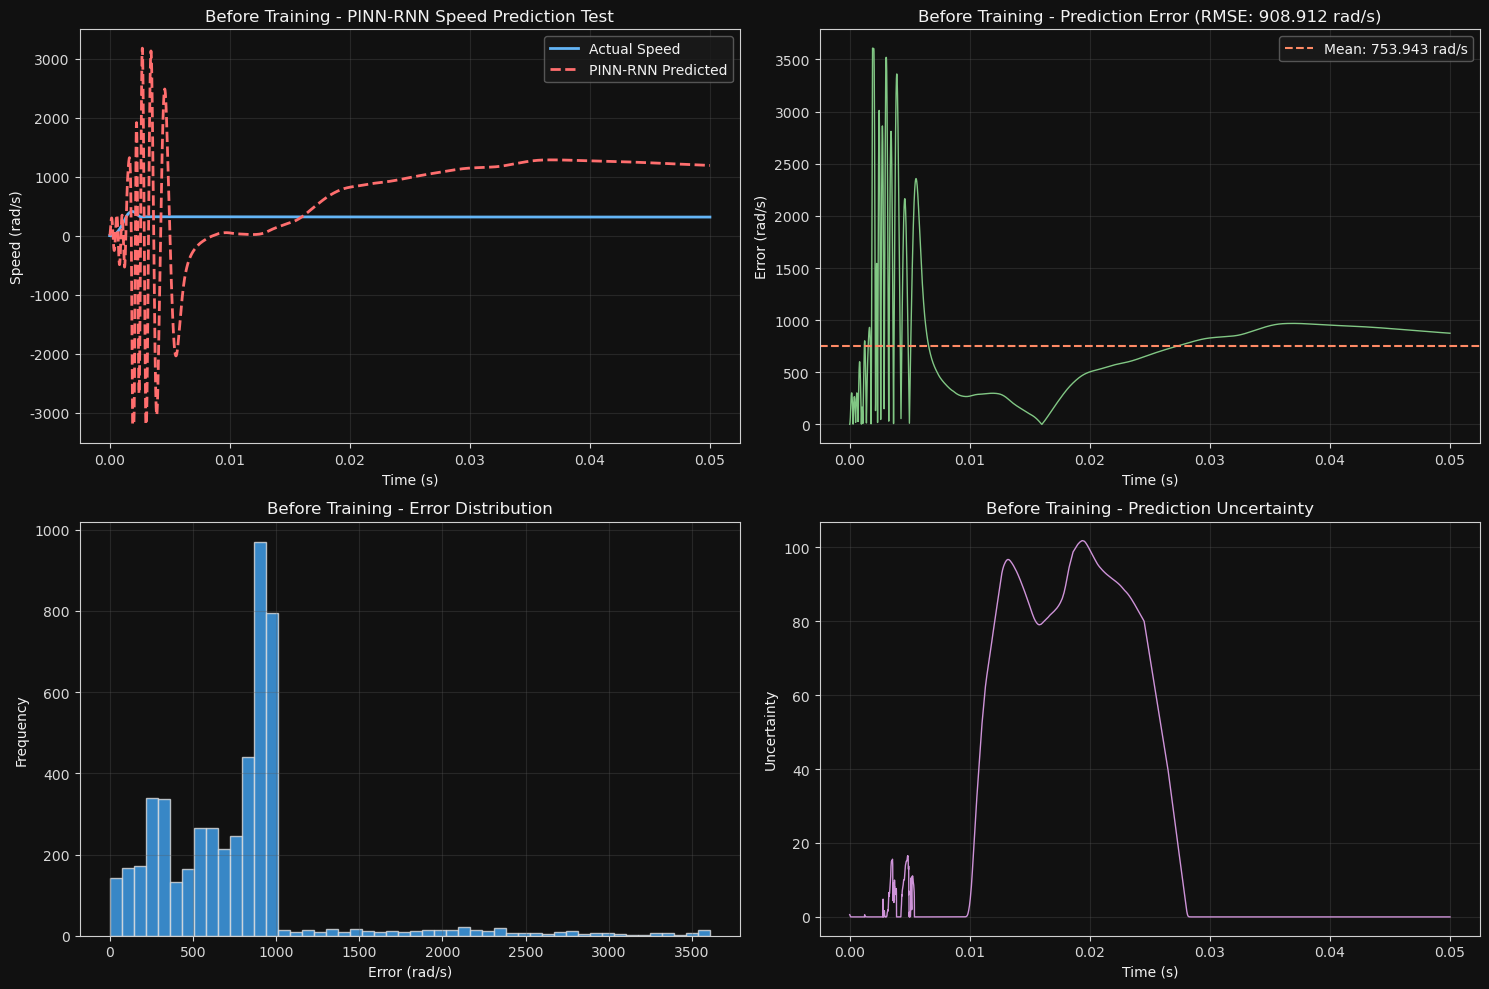


训练阶段
开始PINN-RNN训练（多阶段策略）...
总仿真步数: 99999
批次大小: 128
训练间隔: 1000

训练阶段:
  阶段1: 低速轻载 ramp-up         | 速度= 100.00 rad/s | 负载=  2.0 N·m | 步数= 14999
  阶段2: 低速轻载 steady          | 速度= 100.00 rad/s | 负载=  2.0 N·m | 步数= 14999
  阶段3: 中速中载 ramp-up         | 速度= 200.00 rad/s | 负载=  5.0 N·m | 步数= 14999
  阶段4: 中速中载 steady          | 速度= 200.00 rad/s | 负载=  5.0 N·m | 步数= 14999
  阶段5: 高速重载 ramp-up         | 速度= 314.16 rad/s | 负载= 10.0 N·m | 步数= 14999
  阶段6: 高速重载 steady          | 速度= 314.16 rad/s | 负载= 10.0 N·m | 步数= 14999
  阶段7: 极限负载测试               | 速度= 314.16 rad/s | 负载=200.0 N·m | 步数=  9999
[训练] Step   1000/99999 | Phase: 低速轻载 ramp-up         | Speed Ref:  100.00 | Load:   2.0 | Avg Loss: 0.000000 | Actual Speed:  101.12 | Buffer: 1001 | Elapsed: 1.1s
[训练] Step   2000/99999 | Phase: 低速轻载 ramp-up         | Speed Ref:  100.00 | Load:   2.0 | Avg Loss: 4.409697 | Actual Speed:  100.62 | Buffer: 2001 | Elapsed: 9.7s
[训练] Step   3000/99999 | Phase: 低速轻载 ramp-up         | Speed Ref:  100.00 | Load:   

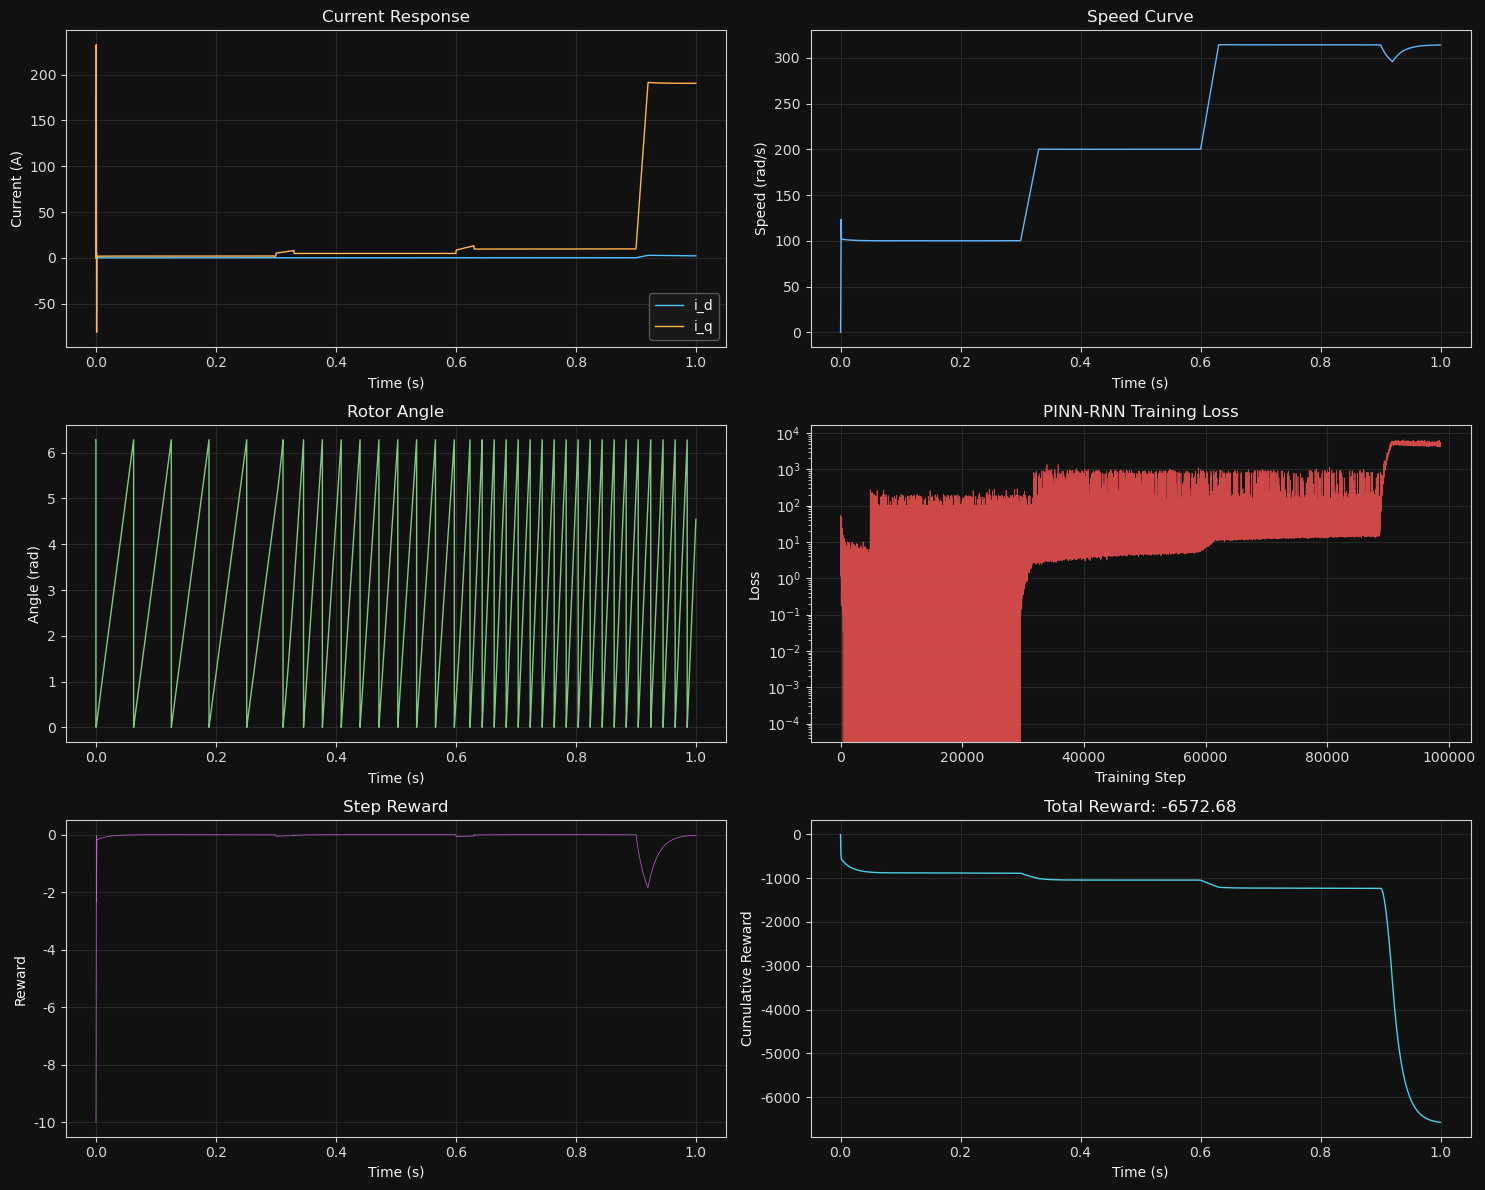


训练后测试阶段

开始PINN-RNN测试...
测试模式: one_step
挑战工况: False
输入噪声标准差: 0.0
测试时间: 0.05s
测试步数: 5000
目标速度: 314.16 rad/s
负载转矩: 50.00 N·m
[测试] Step  100/5000 | Actual:    169.19 rad/s | Pred:    170.48 rad/s | Error:    1.291 rad/s
[测试] Step  200/5000 | Actual:    404.00 rad/s | Pred:    404.13 rad/s | Error:    0.130 rad/s
[测试] Step  300/5000 | Actual:    319.39 rad/s | Pred:    319.18 rad/s | Error:    0.212 rad/s
[测试] Step  400/5000 | Actual:    319.38 rad/s | Pred:    319.65 rad/s | Error:    0.271 rad/s
[测试] Step  500/5000 | Actual:    319.08 rad/s | Pred:    319.36 rad/s | Error:    0.271 rad/s
[测试] Step  600/5000 | Actual:    318.81 rad/s | Pred:    319.08 rad/s | Error:    0.271 rad/s
[测试] Step  700/5000 | Actual:    318.55 rad/s | Pred:    318.82 rad/s | Error:    0.271 rad/s
[测试] Step  800/5000 | Actual:    318.30 rad/s | Pred:    318.57 rad/s | Error:    0.271 rad/s
[测试] Step  900/5000 | Actual:    318.06 rad/s | Pred:    318.33 rad/s | Error:    0.270 rad/s
[测试] Step 1000/5000 | Actual: 

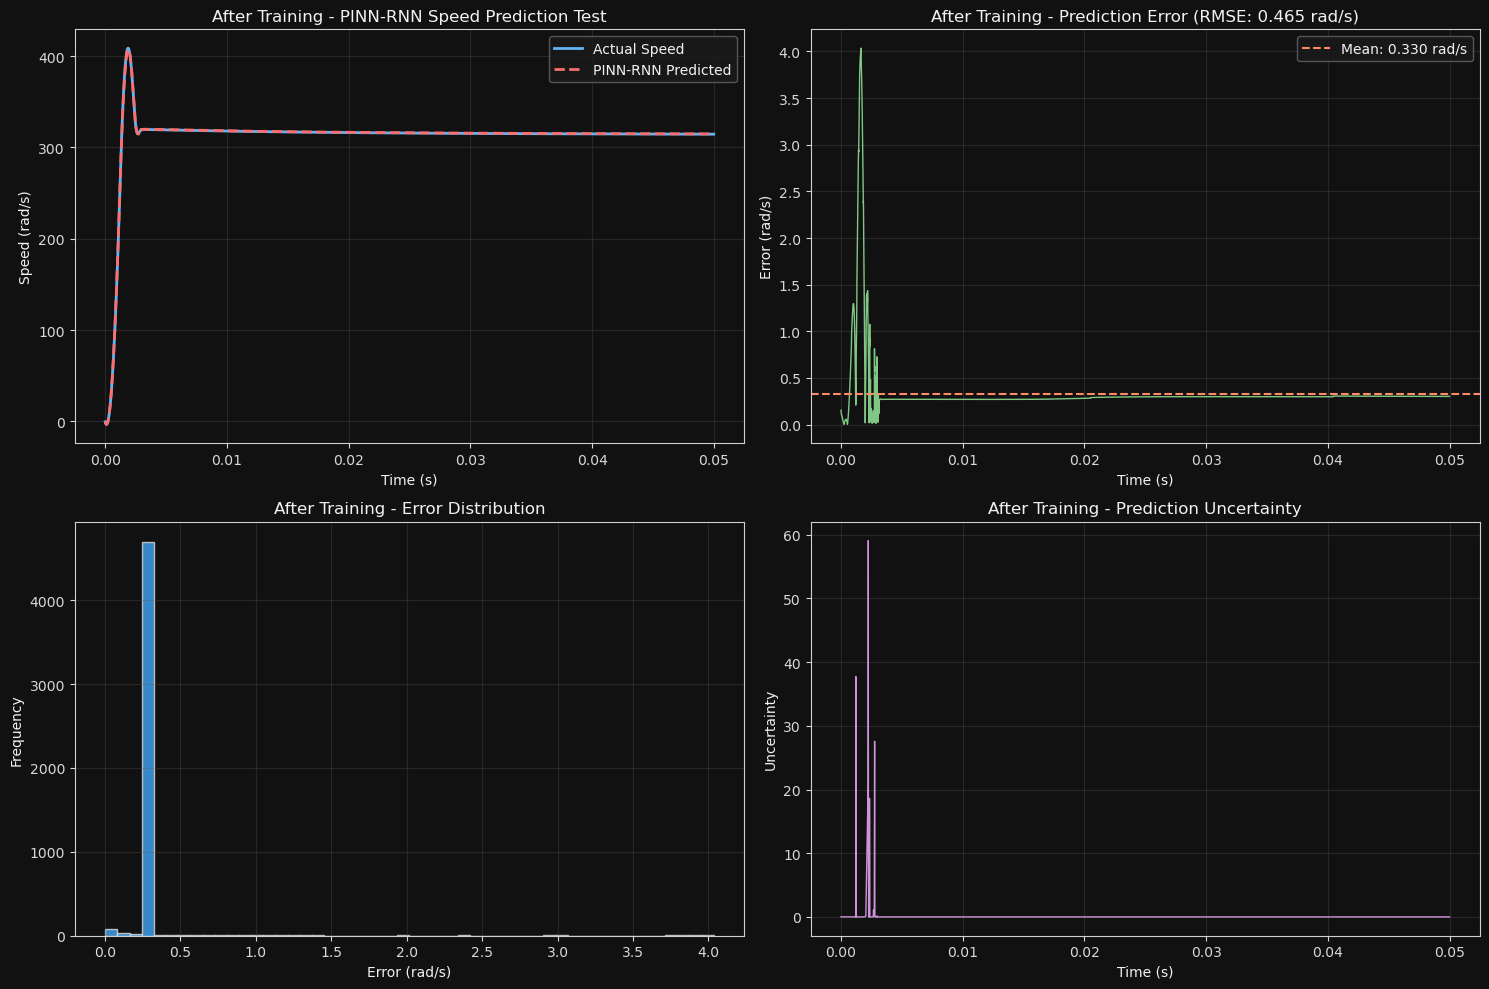


验证阶段

开始PINN-RNN验证...

验证场景: LowSpeed-LightLoad
----------------------------------------

开始PINN-RNN测试...
测试模式: one_step
挑战工况: False
输入噪声标准差: 0.0
测试时间: 0.1s
测试步数: 10000
目标速度: 100.00 rad/s
负载转矩: 20.00 N·m
[测试] Step  100/10000 | Actual:    118.86 rad/s | Pred:    119.37 rad/s | Error:    0.514 rad/s
[测试] Step  200/10000 | Actual:     99.38 rad/s | Pred:     99.81 rad/s | Error:    0.427 rad/s
[测试] Step  300/10000 | Actual:     99.42 rad/s | Pred:     99.84 rad/s | Error:    0.420 rad/s
[测试] Step  400/10000 | Actual:     99.45 rad/s | Pred:     99.87 rad/s | Error:    0.418 rad/s
[测试] Step  500/10000 | Actual:     99.48 rad/s | Pred:     99.89 rad/s | Error:    0.417 rad/s
[测试] Step  600/10000 | Actual:     99.51 rad/s | Pred:     99.92 rad/s | Error:    0.415 rad/s
[测试] Step  700/10000 | Actual:     99.53 rad/s | Pred:     99.95 rad/s | Error:    0.414 rad/s
[测试] Step  800/10000 | Actual:     99.56 rad/s | Pred:     99.97 rad/s | Error:    0.413 rad/s
[测试] Step  900/10000 | Actual:     

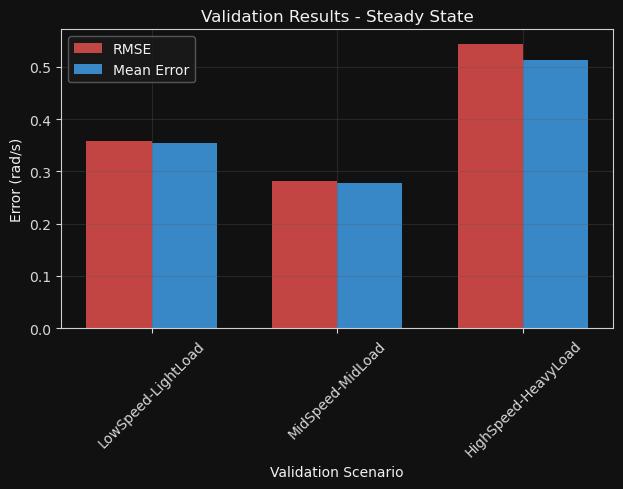


保存结果
训练前测试结果已保存到 pretrain_test_results.npz
训练记录已保存到 training_records.npz
测试结果已保存到 test_results.npz

最终报告

训练前基线测试统计:
  平均误差: 753.943 rad/s
  RMSE: 908.912 rad/s
  最大误差: 3608.561 rad/s
  模式: rollout
  困难工况: False

训练统计:
  总步数: 99999
  总奖励: -6572.68
  最终损失: 4846.0419921875

训练后测试统计:
  平均误差: 0.330 rad/s
  RMSE: 0.465 rad/s
  最大误差: 4.035 rad/s

验证统计:
  LowSpeed-LightLoad: RMSE=0.358 rad/s
  MidSpeed-MidLoad: RMSE=0.281 rad/s
  HighSpeed-HeavyLoad: RMSE=0.545 rad/s
  StepResponse:
    100 rad/s: RMSE=0.253 rad/s
    200 rad/s: RMSE=0.281 rad/s
    300 rad/s: RMSE=0.379 rad/s

程序执行完成！


In [144]:
if __name__ == "__main__":
    # 设置随机种子以确保可重复性
    np.random.seed(42)
    torch.manual_seed(42)
    random.seed(42)

    # 运行主函数
    results = main()